In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [40]:
from pytorch_eo.datasets.vacant_lot_detection.VLD import VLDDatasetDetection, VLDSegmentationDataset

In [54]:

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import torch

def plot_bbox_sample(ds, index=0):
    sample = ds[index] if hasattr(ds, '__getitem__') else ds.ds[index]
    image = sample["image"]
    bbox = sample["bbox"]
    label = sample["label"]

    # Si no es tensor, asumimos que es np.ndarray y normalizamos
    if isinstance(image, torch.Tensor):
        image = image.permute(1, 2, 0).numpy()
    else:
        image = image.astype("float32") / 255.0  # asegurar rango válido para imshow

    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(image)
    x, y, w, h = bbox
    rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='red', facecolor='none')
    ax.add_patch(rect)
    ax.set_title(f"Label: {label}")
    plt.axis("off")
    plt.show()

import torch
import matplotlib.pyplot as plt

def plot_segmentation_sample(ds, index=0):
    sample = ds[index] if hasattr(ds, '__getitem__') else ds.ds[index]
    image = sample["image"]
    mask = sample["mask"]

    if isinstance(image, torch.Tensor):
        image = image.permute(1, 2, 0).numpy()
    else:
        image = image.astype("float32") / 255.0

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(image, interpolation='nearest')
    axes[0].set_title("Image")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap='gray', interpolation='nearest')
    axes[1].set_title("Mask")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

Train samples: 1697
Val samples: 425
Test samples: N/A


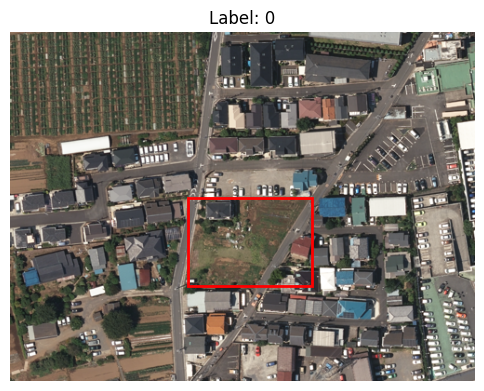

In [47]:
# Detección
ds_det = VLDDatasetDetection(path="/fastdata/VacantLotDetection")
ds_det.setup()
plot_bbox_sample(ds_det.train_ds, index=50)

Train: 2122, Val: 531


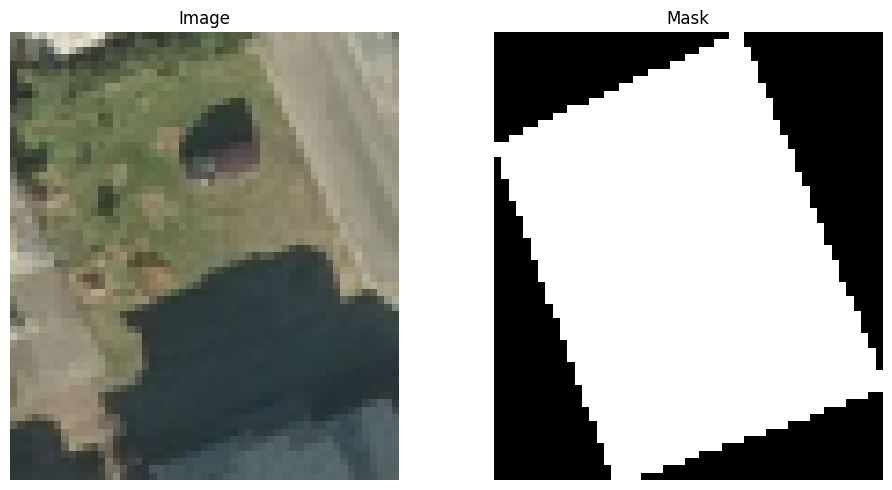

In [68]:
# Segmentación
ds_seg = VLDSegmentationDataset(path="/fastdata/VacantLotDetection")
ds_seg.setup()
plot_segmentation_sample(ds_seg.train_ds, index=0)

In [3]:
from pytorch_eo.tasks.classification import ImageClassification


In [1]:
import torch.nn as nn
import torchvision
import torch

class DetectionTask(nn.Module):
    def __init__(self, num_classes=1, pretrained=True):
        super().__init__()
        self.model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=pretrained)
        in_features = self.model.roi_heads.box_predictor.cls_score.in_features
        self.model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(
            in_features, num_classes + 1  # background + vacant_lot
        )

    def forward(self, images, targets=None):
        if self.training:
            return self.model(images, targets)
        else:
            return self.model(images)

In [ ]:
import lightning as L
from pytorch_eo.datasets.vacant_lot_detection.VLD import VLDDatasetDetection

# Dataset
ds = VLDDatasetDetection(path="/fastdata/VacantLotDetection")
ds.setup()

model = DetectionTask(num_classes=1)  

# Lightning Trainer
trainer = L.Trainer(
    accelerator="gpu",  # o "cpu"
    devices=1,
    max_epochs=5,
    log_every_n_steps=10
)

# Entrenamiento
trainer.fit(model, ds)



Train samples: 1697
Val samples: 425
Test samples: N/A


/home/hector/Projects/pytorchEO/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/hector/Projects/pytorchEO/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /home/hector/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:02<00:00, 76.1MB/s] 
You are using the plain ModelCheckpoint callback. Consider using Li

TypeError: `model` must be a `LightningModule` or `torch._dynamo.OptimizedModule`, got `DetectionTask`